In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Read .dat file
def read_dat_file(filename):
    data = np.loadtxt(filename)
    k = data[:, 0]  # First column: k values
    Pk = data[:, 1]  # Second column: P(k) values
    return k, Pk

# Defile the new transition function
def Transfer_func( k, alpha, beta, gamma ):
    """
    Transition function for general nCDM models, per (Vid Irsic et al 2024),
    
    k = wavenumber [h/Mpc]

    alpha, beta, gamma = free parameters
    """
    return (1 + (k * alpha) ** beta) ** gamma

In [2]:
# Reading Files from the original P_CDM(k)
file = read_dat_file("class_pk_99.dat")

# WDM best fit parameters from Keir 2021
WDM_parameters = [0.02, 2.2, -4.5]

# Calculate the WDM P(k) using the transfer function P_mCDM = T^2 * P_CDM
WDM_pk = Transfer_func(file[0], *WDM_parameters)**2 * file[1]

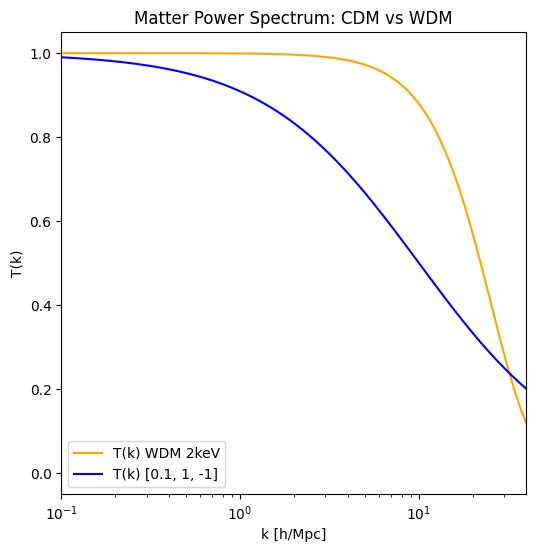

In [17]:
# Plot the results
plt.figure(figsize=(6, 6))
plt.plot(file[0], Transfer_func(file[0], *WDM_parameters), label='T(k) WDM 2keV', color='orange')
plt.plot(file[0], Transfer_func(file[0], 0.1, 1, -1), label='T(k) [0.1, 1, -1]', color='blue')
plt.xlabel('k [h/Mpc]')
plt.ylabel('T(k)')
plt.title('Matter Power Spectrum: CDM vs WDM')
plt.xscale('log')
plt.xlim(0.1, 10**1.6)
plt.legend()

In [5]:
# Save file
np.savetxt("WDM_pk_99.dat", np.column_stack((file[0], WDM_pk)), header="k [h/Mpc]    P(k) [(Mpc/h)^3]", fmt="%e")